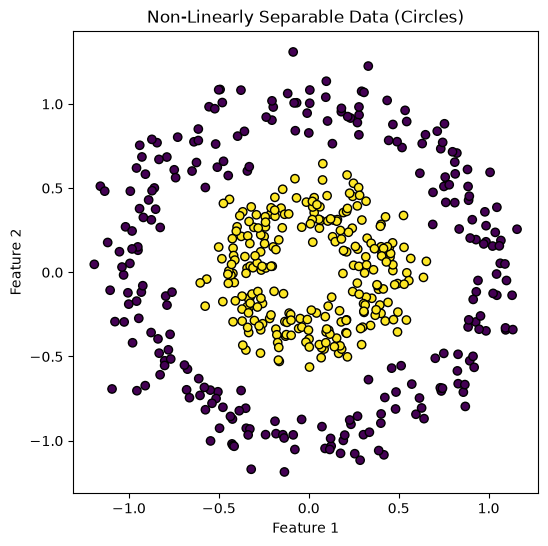

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Generate dataset
X, y = make_circles(
    n_samples=500,
    noise=0.1,
    factor=0.4,
    random_state=42
)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', edgecolors='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Non-Linearly Separable Data (Circles)")
plt.show()

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [6]:
model = Sequential()

model.add(Dense(128,input_dim=2,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

adam = Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

history = model.fit(X,y,epochs=500,validation_split=0.2,verbose=False)

/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


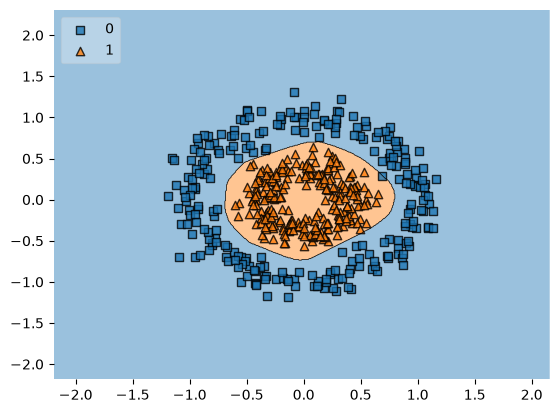

In [7]:
from mlxtend.plotting import plot_decision_regions

class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(X, verbose=0)
        return (pred > 0.5).astype(int).ravel()

wrapped_model = ModelWrapper(model)

plot_decision_regions(
    X,
    y.astype(int),
    clf=wrapped_model,
    legend=2
)

plt.show()